In [ ]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

In [ ]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)
import qiskit
print(qiskit.__version__)
import qiskit_aer
print(qiskit_aer.__version__)

0.45.0
2.3.0
0.17.2


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, SamplerV2
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer.noise import NoiseModel, pauli_error

In [ ]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="LFsogztwnQVatNMK70c2hV_PMd7h_2-5vYl8zvCBI24p", overwrite=True)

Step1: Transformation (Repetition of qubits): Encode the information $|ψ⟩$ by using entanglement.
|Ψ⟩ = α|0⟩ + β|1⟩

|Ψ⟩|00⟩ =>(entanglement) α|000⟩+β|111⟩

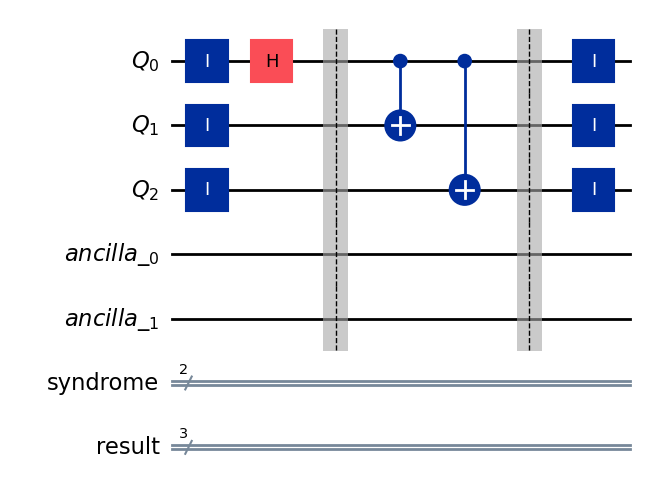

In [ ]:
# 3 data qubits, 2 ancilla qubits, 2 syndrome bits

q_data = QuantumRegister(3, 'Q')
q_ancilla = QuantumRegister(2, 'ancilla_')
c_syn = ClassicalRegister(2, 'syndrome')
result_bit = ClassicalRegister(3, 'result')  # To measure the final state
qc = QuantumCircuit(q_data, q_ancilla, c_syn, result_bit)

# Encode: |ψ⟩|00> -> α|000⟩+β|111⟩
# We start with Q0 in α|0⟩ + β|1⟩ and spread it to Q1 and Q2
qc.id(q_data[0])
qc.id(q_data[1])
qc.id(q_data[2])
qc.h(q_data[0])
qc.barrier()

qc.cx(q_data[0], q_data[1])
qc.cx(q_data[0], q_data[2])
qc.barrier()
qc.id(q_data[0])
qc.id(q_data[1])
qc.id(q_data[2])
qc.draw(output="mpl")

Simulate an Error: Manually inject a bit-flip (X gate) on one of the data qubits to test the circuit.

In [ ]:
# Construct a 10% bit-flip error
p_error = 0.1
bit_flip = pauli_error([("X", p_error), ("I", 1 - p_error)])

# Add error to a NoiseModel
# We'll trigger the error every time the simulator sees an 'id' gate
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(bit_flip, ['h', 'id'])


Step 2: Syndrome Extraction: Use the ancilla qubits to perform parity checks $(Z_{1}Z_{2})$ and $(Z_{2}Z_{3})$ without measuring the data qubits directly.

In [ ]:
# Syndrome Extraction (Stabilizer Measurements)
# Check parity of Q0 and Q1
qc.cx(q_data[0], q_ancilla[0])
qc.cx(q_data[1], q_ancilla[0])

# Check parity of Q1 and Q2
qc.cx(q_data[1], q_ancilla[1])
qc.cx(q_data[2], q_ancilla[1])

qc.barrier()

# Measure the Syndrome (Measure ancillas to get the syndrome)
qc.measure(q_ancilla, c_syn)

Step 3: Correction: Apply conditional logic using the if_test instruction to flip the corrupted qubit based on the measured syndrome.

In [ ]:
# Note: syndrome is read as (ancilla_1)(ancilla_0)
# If syndrome is '01' (binary 1), qubit Q0 (1st bit) is flipped (based on parity logic)
with qc.if_test((c_syn, 1)):
    qc.x(q_data[0])

# Additional cases for syndromes '10'(binary 2) (qubit Q2-3rd bit) and '11' (binary 3) (qubit Q1-Second bit)
with qc.if_test((c_syn, 2)):
    qc.x(q_data[2])

with qc.if_test((c_syn, 3)):
    qc.x(q_data[1])

qc.barrier()

#Final Measurement (Verify the logical state is back to |1>)
# We measure Q0; if correction worked, it should be 1 with 100% probability
qc.measure(q_data, result_bit)

# Run Simulation
sim = AerSimulator(noise_model = noise_model)
job = sim.run(qc, shots=1000)
counts = job.result().get_counts()

print("Measurement Counts (Format: Result Syndrome):", counts)

Measurement Counts (Format: Result Syndrome): {'111 11': 82, '111 10': 65, '111 01': 49, '000 11': 80, '000 10': 64, '000 00': 318, '000 01': 48, '111 00': 294}


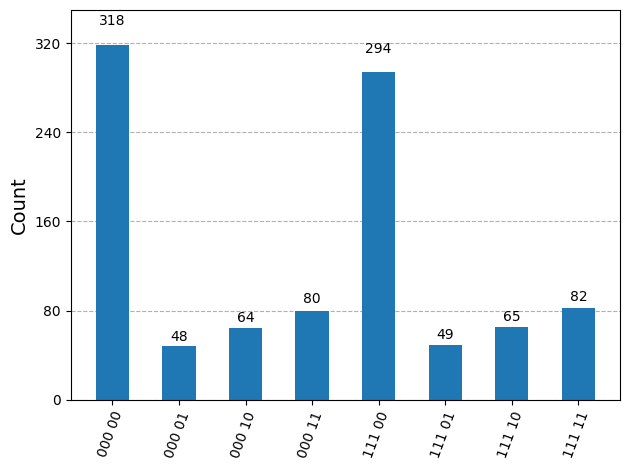

In [ ]:
#histogram for results
from qiskit.visualization import plot_histogram
plot_histogram(counts)